# Stage II — Task 1: Descriptive Statistics
**Dataset:** data/newdata.csv  
**Team:** Group 3  
**Topic:** Movie Revenue Forecasting (TMDB)


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

In [2]:
df = pd.read_csv("data/newdata.csv")

In [3]:
features = ["budget", "runtime", "vote_count"]

In [4]:
for col in features:
    series = df[col].dropna()
    print(f"--- {col} ---")
    print("Mean:", series.mean())
    print("Median:", series.median())
    print("Variance:", series.var())
    print("Skewness:", skew(series))
    print("Kurtosis:", kurtosis(series))
    print()

--- budget ---
Mean: 37042837.631704725
Median: 23000000.0
Variance: 1818725193505032.2
Skewness: 2.2234187352440666
Kurtosis: 6.3526197201724095

--- runtime ---
Mean: 106.87424526337706
Median: 103.0
Variance: 511.09288715932485
Skewness: 0.7160808139021895
Kurtosis: 8.929776785337287

--- vote_count ---
Mean: 690.2179887570269
Median: 235.0
Variance: 1524202.321692161
Skewness: 3.8228741568608937
Kurtosis: 19.89197253000306



### Task 1b — Data Types
- **Budget** → Numerical (continuous)  
- **Runtime** → Numerical (continuous)  
- **Vote Count** → Numerical (discrete)  


I used **budget**, **runtime**, and **vote_count** because we already cleaned them in Stage I and they’re clearly numeric.  

- Budget and vote_count are both skewed (a few movies have huge budgets or way more votes than most).  
- Runtime is more centered around 90–120 minutes, so mean and median are close.  
- Budget and runtime are continuous values, while vote_count is discrete.  


## Task 2 - Distribution Fitting

#### a. Select one suitable numerical feature from task 1. Propose a theoretical distribution (Normal, Binomial, Poisson, Exponential, Geometric, etc.) and explain why you choose it. (6 points)

##### For the feature "Budget" since usually movies with higher budgets perform better however there have been outliers and would like to see distribution. I do also believe that the best distribution to fit this feature would be Exponential and right skewed due to most movies not having the insane budget as blockbusters would.

#### b. Plot histogram of your feature, overlay a smooth curve of the fitted theoretical distribution (10 points). Discuss how your data fits the distribution. (4 points)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

df = pd.read_csv("data/newdata.csv")

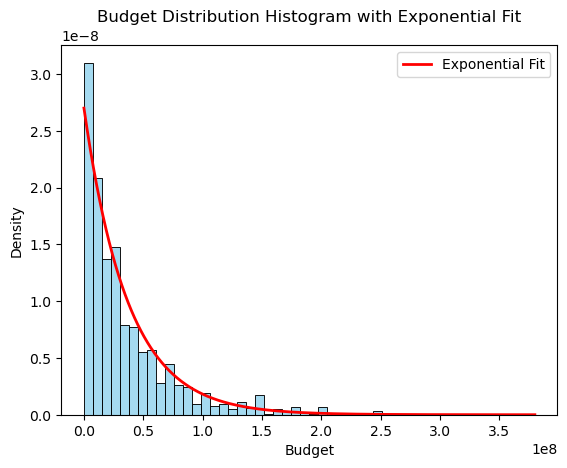

In [6]:
budget = df['budget'].dropna()

sns.histplot(budget, kde=False, stat="density", bins=50, color="skyblue")

loc, scale= stats.expon.fit(budget, floc=0)

x= np.linspace(budget.min(), budget.max(), 1000)
pdf= stats.expon.pdf(x, loc, scale)

plt.plot(x, pdf, 'r-', lw=2, label="Exponential Fit")

plt.title("Budget Distribution Histogram with Exponential Fit")
plt.xlabel("Budget")
plt.ylabel("Density")
plt.legend()
plt.show()

##### As hypothesized above, the distribution is an exponential right skewed dataset. The Exponential Fit line also matches the distribution to show the curve and directly shows how most movies are "low budget" with very few extreme high budget movies.

# Task 3 - Point Estimate 

- a. Randomly select 100 samples from the feature (budget) selected in Task 2, caculate the sample mean and variance. Compare with the population mean and variance. 

In [15]:
import numpy as np

# Feature from Task 2
budget = df["budget"].dropna()

# Population statistics
pop_mean = budget.mean()
pop_var = budget.var()

print("Population Mean:", pop_mean)
print("Population Variance:", pop_var)

# Randomly select 100 samples
sample = budget.sample(100, replace=False)

# Sample statistics
sample_mean = sample.mean()
sample_var = sample.var()

print("\nSample Mean (n=100):", sample_mean)
print("Sample Variance (n=100):", sample_var)

Population Mean: 37042837.631704725
Population Variance: 1818725193505032.2

Sample Mean (n=100): 38701301.16
Sample Variance (n=100): 1961049778020524.5


- b. Repeat the random sampling 3 times and show how sample mean/variance vary due to randomness. Discuss your findings.

In [18]:
# Repeat random sampling 3 times
for i in range(1, 4):
    sample = budget.sample(100, replace=False)
    sample_mean = sample.mean()
    sample_var = sample.var()
    print(f"Sample {i} Mean: {sample_mean}, Variance: {sample_var}")

Sample 1 Mean: 40245250.0, Variance: 2300872561300501.5
Sample 2 Mean: 42546408.0, Variance: 2268685629236299.0
Sample 3 Mean: 37079225.12, Variance: 1905174910336728.0


The population mean of budget was 37042837.631704725, with a variance of 1818725193505032.2. When taking a random sample of 100 movies, the sample mean and sample variance were close, but not identical.

After repeating the sampling 3 times, the sample means and variances varied slightly. Some samples overestimated the population mean, while others underestimated it. This happens because each random set of 100 movies captures a slightly different value of the dataset.